#뉴스 카테고리 분류(자연어 처리)

# 서론

목표 : 텍스트 데이터를 입력으로 받아 뉴스의 카테고리를 예측하는 딥 러닝 모델 구현

활용 데이터셋 : sklearn.dataset의 fetch_20newsgroups

## 목차

1. 데이터 불러오기 / EDA
2. 데이터 전처리
3. 모델링
4. 학습 / 모델 비교
5. 하이퍼파라미터 튜닝
6. 결론 도출

## 활용 모델

GRU

- LSTM 대비 파라미터 수가 적어 학습이 빠르고 과적합 위험이 낮음
- 데이터셋 규모가 크지 않은 실습 환경에 적합
baseline 모델로 선정

Bi-GRU

- 단방향 GRU는 앞→뒤 방향만 학습하지만, 양방향으로 문맥을 파악하면 텍스트 분류 성능 향상 기대
- GRU 대비 성능 개선 확인 목적

Bi-GRU + Attention

- Bi-GRU의 마지막 hidden state만 사용하는 한계를 보완
- 중요한 단어에 집중하는 Attention 메커니즘 추가로 추가적인 성능 향상 기대

# 1\. 데이터 불러오기 / EDA

## pip/imports

In [1]:
!pip install sentencepiece

In [2]:
!pip install gensim

In [3]:
!pip install torchmetrics

In [4]:
!pip install optuna

In [60]:
from sklearn.datasets import fetch_20newsgroups
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import sentencepiece as spm
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from gensim.models import Word2Vec
from torchmetrics import F1Score
import time
import optuna
from collections import Counter
from torchmetrics import ConfusionMatrix

##1-1. 데이터 불러오기

In [6]:
# 훈련 데이터와 테스트 데이터를 모두 가져옴
news_data = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))

#Dataframe 변환
df = pd.DataFrame({
    'text': news_data.data,
    'label': news_data.target
})

df.head(5)

,text,label
0,\n\nI am sure some bashers of Pens fans are pr...,10
1,My brother is in the market for a high-perform...,3
2,\n\n\n\n\tFinally you said what you dream abou...,17
3,\nThink!\n\nIt's the SCSI card doing the DMA t...,3
4,1) I have an old Jasmine drive which I cann...,4


## 1-2. EDA

### a) 결측치/이상치 확인

In [7]:
# 결측치 확인
print("결측치 확인")
print(df.isnull().sum())
print()

# 빈 문자열 확인
print(f"빈 문자열 수: {(df['text'] == '').sum()}")
print()

# 공백만 있는 문자열 확인
print(f"공백만 있는 문자열 수(빈 문자열 포함): {(df['text'].str.strip() == '').sum()}")

결측치 확인
text     0
label    0
dtype: int64

빈 문자열 수: 380

공백만 있는 문자열 수(빈 문자열 포함): 515


실질적으로 내용이 없는 문서가 515장 있어서, 전처리 단계에서 제거하기로 결정

### b) 클래스 분포 확인

In [8]:
# label 숫자를 카테고리 이름으로 변환해서 새 컬럼 추가
df['label_name'] = df['label'].map(lambda x: news_data.target_names[x])

In [9]:
df['label_name'].value_counts()

,count
label_name,
rec.sport.hockey,999
soc.religion.christian,997
rec.motorcycles,996
rec.sport.baseball,994
sci.crypt,991
rec.autos,990
sci.med,990
comp.windows.x,988
sci.space,987


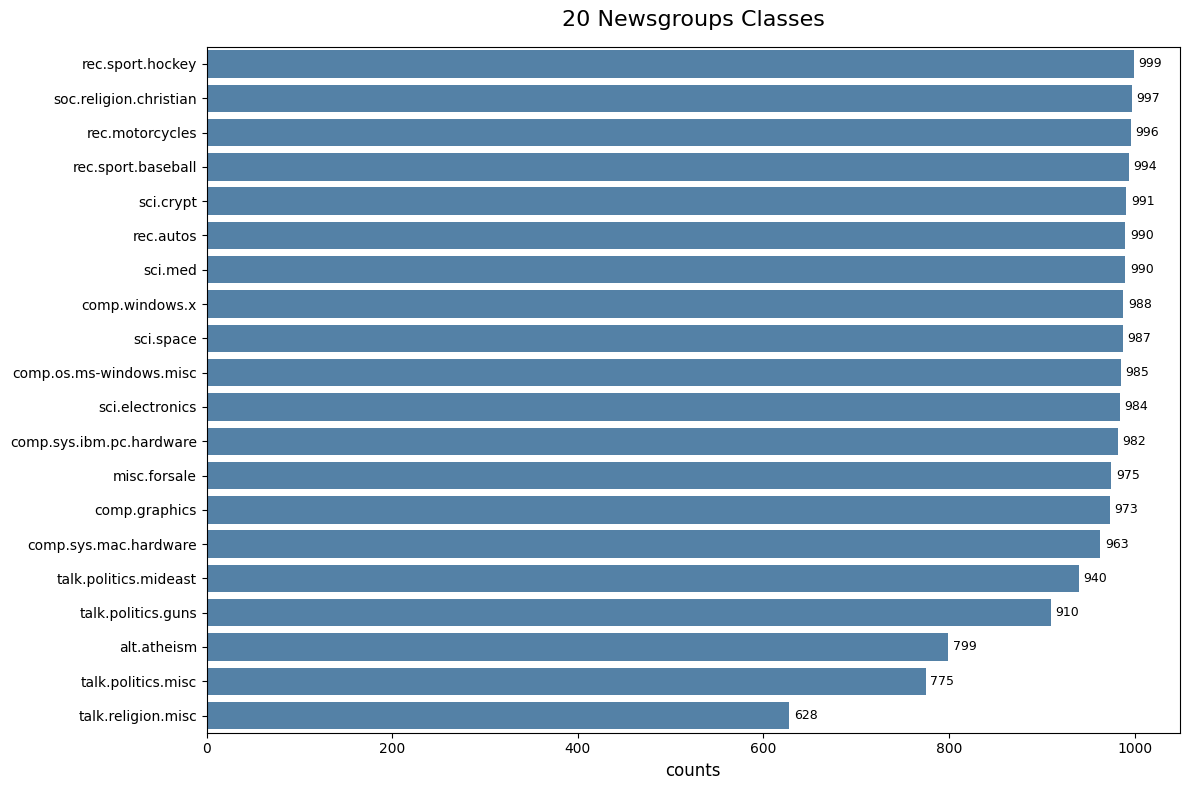

In [10]:
#클래스 분포 시각화

plt.figure(figsize=(12, 8))

counts = df['label_name'].value_counts()

sns.barplot(x=counts.values, y=counts.index,
            hue=counts.index, palette=['steelblue'] * len(counts), legend=False)

plt.title('20 Newsgroups Classes', fontsize=16, pad=15)
plt.xlabel('counts', fontsize=12)
plt.ylabel('')

# 각 바에 숫자 표시
for i, v in enumerate(counts.values):
    plt.text(v + 5, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

talk.religion.misc가 628개로 적어서 살짝 불균형하지만, 전반적으로 균형잡혀있는 클래스 분포를 보여 불균형 처리는 따로 필요없을 듯 싶다.

### c) 텍스트 길이 확인

In [11]:
# 텍스트 길이 column 추가
df['text_length'] = df['text'].apply(lambda x: len(x.split()))

print("=== 텍스트 길이 통계 ===")
print(df['text_length'].describe())

=== 텍스트 길이 통계 ===
count    18846.000000
mean       181.637748
std        501.333800
min          0.000000
25%         40.000000
50%         83.000000
75%        166.000000
max      11765.000000
Name: text_length, dtype: float64


- 평균이 181단어인데, 중앙값이 83단어인 점, 표준편차가 501로 매우 큰점을 보아 극단적으로 긴 문서들이 평균을 많이 끌어올리는 것으로 보인다.

- 따라서 극단적으로 긴 문서들을 배제하기 위해서, quantile을 활용하여 패딩길이를 정하기로 했다.

In [12]:
# 분포 더 자세히 확인
print(f"90th percentile: {df['text_length'].quantile(0.9):.0f}")
print(f"95th percentile: {df['text_length'].quantile(0.95):.0f}")
print(f"99th percentile: {df['text_length'].quantile(0.99):.0f}")

90th percentile: 331
95th percentile: 558
99th percentile: 1751


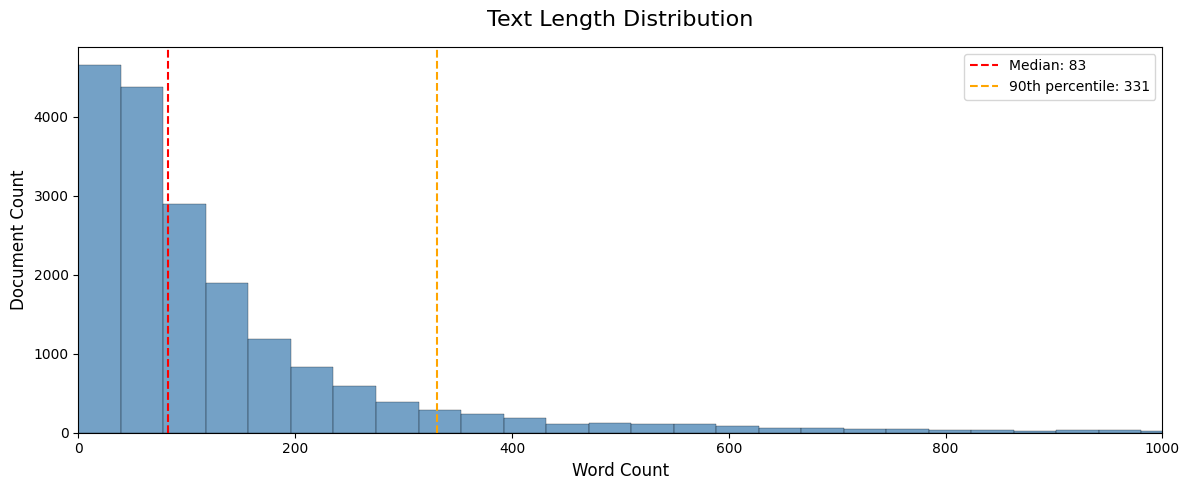

In [13]:
plt.figure(figsize=(12, 5))

sns.histplot(df['text_length'], bins=300, color='steelblue')

plt.title('Text Length Distribution', fontsize=16, pad=15)
plt.xlabel('Word Count', fontsize=12)
plt.ylabel('Document Count', fontsize=12)
plt.xlim(0, 1000)
plt.axvline(df['text_length'].median(), color='red', linestyle='--',
            label=f"Median: {df['text_length'].median():.0f}")
plt.axvline(df['text_length'].quantile(0.9), color='orange', linestyle='--',
            label=f"90th percentile: {df['text_length'].quantile(0.9):.0f}")
plt.legend()
plt.tight_layout()
plt.show()

- 대부분 문서가 100단어 이하로 집중되어 있는걸 확인

- 90분위수(331)기준으로 문서의 갯수가 급격히 줄어드는 것으로 보아, 토큰의 max_len을 300으로 잡고, 추후에 성능을 향상시킬 때 max_len을 바꿔보는 것도 고려사항에 넣을 수 있을 것 같다.

# 2\. 전처리

## 2-1. 텍스트 클렌징

In [14]:
#전처리용 함수 clean_text 정의
def clean_text(text):
    # 이메일 헤더 제거
    text = re.sub(r'^[\w\-]+:.*$', '', text, flags=re.MULTILINE)

    # 이메일 주소 제거
    text = re.sub(r'\S+@\S+', '', text)

    # URL 제거
    text = re.sub(r'http\S+|www\S+', '', text)

    # HTML 태그 제거
    text = re.sub(r'<.*?>', '', text)

    # 특수문자 제거 (문장부호 제외)
    text = re.sub(r'[^a-zA-Z\s\.\!\?]', '', text)

    # 소문자화
    text = text.lower()

    # 중복 공백 제거
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [15]:
# 해당 함수 적용
df['text_clean'] = df['text'].apply(clean_text)

# 적용되었는지 확인
print(df['text'].iloc[0])
print("=====")
print(df['text_clean'].iloc[0])



I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However, I am going to put an end
to non-PIttsburghers' relief with a bit of praise for the Pens. Man, they
are killing those Devils worse than I thought. Jagr just showed you why
he is much better than his regular season stats. He is also a lot
fo fun to watch in the playoffs. Bowman should let JAgr have a lot of
fun in the next couple of games since the Pens are going to beat the pulp out of Jersey anyway. I was very disappointed not to see the Islanders lose the final
regular season game.          PENS RULE!!!


=====
i am sure some bashers of pens fans are pretty confused about the lack of any kind of posts about the recent pens massacre of the devils. actually i am bit puzzled too and a bit relieved. however i am going to put an end to nonpittsburghers relief with a bit of praise for the pens

## 2-2.토큰화(nltk,spm 활용), 정수 인코딩

In [16]:
#토큰화 - nltk 활용
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [17]:
# 학습 데이터를 txt 파일로 저장
with open('news_data.txt', 'w', encoding='utf-8') as f:
    for text in df['text_clean']:
        f.write(text + '\n')

In [18]:
# 저장 경로 생성
os.makedirs('./model', exist_ok=True)

spm.SentencePieceTrainer.train(input='news_data.txt', # 텍스트 뭉치 파일
                            model_prefix='./model/news_spm',       # 출력 모델 파일 이름
                            vocab_size=8000,                       # 토큰 개수
                            pad_id=0,                      # pad 토큰 ID
                            unk_id=1,                      # unknown 토큰 ID
                            bos_id=2,                      # 문장 시작토큰 ID
                            eos_id=3,                      # 문장 끝 토큰 ID
                            )

In [19]:
# 모델 로드
sp = spm.SentencePieceProcessor()
sp.load('./model/news_spm.model')

# 토크나이징 적용
df['tokens'] = df['text_clean'].apply(lambda x: sp.encode(x, out_type=str))

#정수 인코딩 적용
def encode_with_bos_eos(text):
    result = []
    for sent in sent_tokenize(text):
        sent = sent.strip()
        if sent:
            ids = [sp.bos_id()] + sp.encode(sent, out_type=int) + [sp.eos_id()]
            result.extend(ids)
    return result

#해당 함수 apply
df['input_ids'] = df['text_clean'].apply(encode_with_bos_eos)

#확인
print(df['tokens'].iloc[0])       #토큰화된 단어들
print(df['input_ids'].iloc[0])    #정수 인코딩된 단어들

['▁i', '▁am', '▁sure', '▁some', '▁bash', 'ers', '▁of', '▁pens', '▁fans', '▁are', '▁pretty', '▁confused', '▁about', '▁the', '▁lack', '▁of', '▁any', '▁kind', '▁of', '▁posts', '▁about', '▁the', '▁recent', '▁pens', '▁massacre', '▁of', '▁the', '▁devils', '.', '▁actually', '▁i', '▁am', '▁bit', '▁puzzle', 'd', '▁too', '▁and', '▁a', '▁bit', '▁relieve', 'd', '.', '▁however', '▁i', '▁am', '▁going', '▁to', '▁put', '▁an', '▁end', '▁to', '▁non', 'p', 'itt', 's', 'burg', 'her', 's', '▁relief', '▁with', '▁a', '▁bit', '▁of', '▁praise', '▁for', '▁the', '▁pens', '.', '▁man', '▁they', '▁are', '▁killing', '▁those', '▁devils', '▁worse', '▁than', '▁i', '▁thought', '.', '▁jagr', '▁just', '▁showed', '▁you', '▁why', '▁he', '▁is', '▁much', '▁better', '▁than', '▁his', '▁regular', '▁season', '▁stats', '.', '▁he', '▁is', '▁also', '▁a', '▁lot', '▁fo', '▁fun', '▁to', '▁watch', '▁in', '▁the', '▁playoffs', '.', '▁bowman', '▁should', '▁let', '▁jagr', '▁have', '▁a', '▁lot', '▁of', '▁fun', '▁in', '▁the', '▁next', '▁coupl

## 2-3. 데이터셋 구축

데이터셋을 생성한 후, train : val : test를 80 : 10 : 10의 비율로 random split해주었다.

In [20]:
class NewsDataset(Dataset):
    def __init__(self, df, sp, max_len=300):
        self.df = df
        self.sp = sp
        self.max_len = max_len

    def zero_pad(self, tok):
        if len(tok) >= self.max_len:
            return tok[:self.max_len]
        else:
            padding = np.zeros(self.max_len)
            padding[:len(tok)] = tok
            return padding

    def __getitem__(self, i):
        #전처리에서 모두 인코딩, 토큰 처리 완료하였으므로 가져오기만 하기
        inp = self.df.iloc[i]['input_ids']
        tar = self.df.iloc[i]['label']

        # 패딩
        inp = self.zero_pad(inp)
        #long타입으로 return
        return torch.LongTensor(inp), tar

    def __len__(self):
        return len(self.df)

In [21]:
# train/val/test split
train_df, val_test_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(val_test_df, test_size=0.5, random_state=42)

#split하면 원본 df의 인덱스가 유지되므로 reset_index
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Dataset 생성
train_dataset = NewsDataset(train_df, sp)
val_dataset = NewsDataset(val_df, sp)
test_dataset = NewsDataset(test_df, sp)

# DataLoader 생성
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, pin_memory=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, pin_memory=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, pin_memory=True, num_workers=2)

print(f"train: {len(train_dataset)}, val: {len(val_dataset)}, test: {len(test_dataset)}")

train: 15076, val: 1885, test: 1885


# 3\. 모델링

## 3-1. Word2Vec 임베딩 초기값 설정

In [22]:
#Word2Vec 모델 학습(tokens column 활용)

embedding_dim = 64

w2v_model = Word2Vec(
    sentences=df['tokens'].tolist(),  # 학습 데이터 (토큰 리스트)
    vector_size=64,                  # 임베딩 벡터 크기
    window=5,                         # 주변 단어 참조 범위
    min_count=1,                      # 최소 등장 횟수 (1 = 모든 토큰 학습)
    workers=4,
    epochs=10,                        # 학습 반복 횟수
    sg=1                              # 1 = Skip-gram
)

In [23]:
sp_vocab_size = sp.get_piece_size()  #위에서 8000으로 설정했었음

# sp vocab 크기 x 임베딩 크기의 zeros 행렬 생성 (기본값 0으로 초기화)
embedding_matrix = torch.zeros(sp_vocab_size, embedding_dim)

In [24]:
# 3번 - sp id와 Word2Vec 벡터 매핑
for idx in range(sp_vocab_size):
    # sp id에 해당하는 토큰 가져오기
    token = sp.id_to_piece(idx)

    # Word2Vec 사전에 해당 토큰이 존재하는지 체크
    if token in w2v_model.wv.key_to_index:
        # 존재하면 Word2Vec 벡터를 embedding_matrix에 저장
        embedding_matrix[idx] = torch.tensor(w2v_model.wv[token])
    else:
        # 없으면 0으로 유지
        pass

## 3-2. GRU모델 정의

In [25]:
class GRUModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size=128, num_layers=2, num_classes=20, dropout=0.3):
        super(GRUModel, self).__init__()

        # 임베딩 레이어 (Word2Vec 초기값 적용)
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight = nn.Parameter(embedding_matrix)

        # GRU 레이어
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        #Dropout 레이어
        self.dropout = nn.Dropout(dropout)

        # 분류 레이어
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # 임베딩 레이어
        x = self.embedding(x)  # [batch_size, seq_len, embedding_dim]

        # GRU 순전파
        out, _ = self.gru(x)  # out: [batch_size, seq_len, hidden_size]

        # Global Average Pooling
        pooled = torch.mean(out, dim=1)  # [batch_size, hidden_size]

        #Dropout(과적합 방지)
        pooled = self.dropout(pooled)

        # 분류(최종 출력)
        out = self.fc(pooled)  # [batch_size, num_classes]

        return out


## 3-3. Bi-GRU 모델 정의

In [26]:
class BiGRUModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size=128, num_layers=2, num_classes=20, dropout=0.3):
        super(BiGRUModel, self).__init__()

        # 임베딩 레이어 (Word2Vec 초기값 적용)
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight = nn.Parameter(embedding_matrix)

        # Bi-GRU 레이어
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )

        #Dropout 레이어
        self.dropout = nn.Dropout(dropout)

        # 분류 레이어 (양방향이라 hidden_size * 2)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        # 임베딩 레이어
        x = self.embedding(x)  # [batch_size, seq_len, embedding_dim]

        # 양방향 GRU 순전파
        out, _ = self.gru(x)  # out: [batch_size, seq_len, hidden_size * 2]

        # Global Average Pooling
        pooled = torch.mean(out, dim=1)  # [batch_size, hidden_size * 2]

        #Dropout(과적합 방지)
        pooled = self.dropout(pooled)

        # 분류(최종 출력)
        out = self.fc(pooled)  # [batch_size, num_classes]

        return out

## 3-4. Bi-GRU + Attention 모델 정의

### Attention 클래스

In [27]:
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super(Attention, self).__init__()
        # Attention 가중치 계산 레이어
        self.attn = nn.Linear(hidden_size * 2, 1)

    def forward(self, output):
        # output: [batch_size, seq_len, hidden_size * 2]

        # 각 타임스텝의 가중치 계산
        attn_weights = self.attn(output)  # [batch_size, seq_len, 1]

        # Softmax로 가중치 정규화
        attn_weights = torch.softmax(attn_weights, dim=1)  # [batch_size, seq_len, 1]

        # 가중합으로 context vector 생성
        context = (attn_weights * output).sum(dim=1)  # [batch_size, hidden_size * 2]

        return context

###BiGRU + Attention

In [28]:
class BiGRUAttentionModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size=128, num_layers=2, num_classes=20, dropout=0.3):
        super(BiGRUAttentionModel, self).__init__()

        # 임베딩 레이어 (Word2Vec 초기값 적용)
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight = nn.Parameter(embedding_matrix)

        # 양방향 GRU 레이어
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )

        # Attention 레이어
        self.attention = Attention(hidden_size)

        #Dropout 레이어
        self.dropout = nn.Dropout(dropout)

        # 분류 레이어
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        # 임베딩 레이어
        x = self.embedding(x)  # [batch_size, seq_len, embedding_dim]

        # 양방향 GRU 순전파
        out, _ = self.gru(x)  # out: [batch_size, seq_len, hidden_size * 2]

        # Attention 적용 (mean pooling 대신) + Dropout
        context = self.dropout(self.attention(out))  # [batch_size, hidden_size * 2]

        # 분류(최종 출력)
        out = self.fc(context)  # [batch_size, num_classes]

        return out

#4. 모델 학습

In [29]:
#디바이스 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## 4-1. 반복함수 정의

### 모델학습 함수(history 반환)

In [30]:
def train_test(model, model_name, epochs, hidden_size, num_layers, lr, wd, dropout):

    # Adam 옵티마이저 (weight_decay로 L2 정규화 적용)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    # 다중 클래스 분류 손실함수
    criterion = nn.CrossEntropyLoss()

    # 20개 클래스 macro f1 score (클래스별 f1을 균등하게 평균)
    f1_metric = F1Score(task='multiclass', num_classes=20, average='macro').to(device)

    # 학습 기록 저장용 딕셔너리
    history = {'train_loss':[],
               'val_loss':[],
               'val_acc':[],
               'val_f1':[],
               'time':0.0
               }

    # best 모델 저장용 변수
    best_val_acc = 0.0
    best_model_path = f'./checkpoints/{model_name}_best.pt'
    os.makedirs('./checkpoints', exist_ok=True)

    print('학습 시작')
    start_time = time.time()
    for epoch in range(epochs):
        # 학습 모드 (dropout, batchnorm 활성화)
        model.train()
        total_loss = 0.0

        for input, labels in train_loader:
            # 입력 데이터를 long 타입으로 변환 후 GPU로 이동
            input_ids = input.long().to(device)
            labels = labels.to(device)

            # 순전파
            outputs = model(input_ids)  # [batch_size, num_classes]
            loss = criterion(outputs, labels)  # 손실 계산

            # 역전파 및 가중치 업데이트
            optimizer.zero_grad()  # 이전 그래디언트 초기화
            loss.backward()        # 그래디언트 계산
            optimizer.step()       # 가중치 업데이트

            total_loss += loss.item()

        # 에포크 평균 학습 손실
        avg_loss = total_loss / len(train_loader)
        history['train_loss'].append(avg_loss)
        print(f"Epoch [{epoch + 1}/{epochs}], Train Loss: {avg_loss:.4f}")

        # 평가 모드
        model.eval()
        total_val_loss = 0.0
        total_val_acc = 0.0


        with torch.no_grad():
            for input, labels in val_loader:
                input_ids = input.long().to(device)
                labels = labels.to(device)

                # 순전파
                outputs = model(input_ids)  # [batch_size, num_classes]
                loss = criterion(outputs, labels)
                total_val_loss += loss.item()

                # 가장 높은 확률의 클래스를 예측값으로 선택
                preds = outputs.argmax(dim=1)
                acc = (preds == labels).sum() / len(labels)
                total_val_acc += acc

                # 배치별 예측값을 f1 metric에 누적
                f1_metric.update(preds, labels)

        # 에포크 평균 검증 손실, 정확도, f1 계산
        avg_val_loss = total_val_loss / len(val_loader)
        avg_val_acc = total_val_acc / len(val_loader)
        avg_val_f1 = f1_metric.compute()  # 누적된 예측값으로 f1 계산
        f1_metric.reset()  # 다음 에포크를 위해 초기화

        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(avg_val_acc.cpu().item())
        history['val_f1'].append(avg_val_f1.cpu().item())
        print(f"Val Loss: {avg_val_loss:.4f}, Acc: {avg_val_acc:.4f}, F1: {avg_val_f1:.4f}")

        # best 모델 저장 (val_acc 기준)
        if avg_val_acc > best_val_acc:
            best_val_acc = avg_val_acc
            torch.save(model.state_dict(), best_model_path)
            print(f" Best model saved! Val Acc: {best_val_acc:.4f}")

    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"\n [{model_name} Model] 총 학습 시간: {elapsed_time:.2f}초 ({elapsed_time/60:.2f}분)")
    history['time'] = elapsed_time

    return history

### history 시각화 함수

In [31]:
#history 시각화 함수 정의
def plot_history(history) :
  epochs_range = range(1, len(history['train_loss'])+1)

  plt.figure(figsize=(8, 8))

  # 학습&평가 손실 시각화
  ax1 = plt.subplot(2, 1, 1)
  ax1.plot(epochs_range, history['train_loss'], label= 'train_loss')
  ax1.plot(epochs_range, history['val_loss'], label='val_loss')
  ax1.set_title('Training & Validation Loss')
  ax1.set_xlabel('Epochs')
  ax1.set_ylabel('Loss')
  ax1.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
  ax1.legend()

  # 정확도&F1 지표 시각화
  ax2 = plt.subplot(2, 1, 2)
  ax2.plot(epochs_range, history['val_acc'], label='val_acc')
  ax2.plot(epochs_range, history['val_f1'], label='val_f1')
  ax2.set_title('Validation Accuracy & F1 Score')
  ax2.set_xlabel('Epochs')
  ax2.set_ylabel('Score')
  ax2.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
  ax2.legend()


  plt.legend()
  plt.tight_layout()
  plt.show()

## 4-2.모델 학습

모델 학습은 모두 동일한 기준으로 진행했다.

|기준|값|
|:---:|:---:|
|epochs|10|
|hidden_size|64|
|num_layers|2|
|lr|0.001|
|wd|1e-5|
|dropout|0.5|

### a) GRU

In [32]:
# GRU 모델 학습
gru_model = GRUModel(vocab_size=8000, embedding_dim=64).to(device)
gru_history = train_test(gru_model, 'GRU', epochs = 10, hidden_size=64, num_layers=2, lr=0.001, wd=1e-5, dropout=0.5)

학습 시작
Epoch [1/10], Train Loss: 2.8917
Val Loss: 3.0406, Acc: 0.0620, F1: 0.0085
 Best model saved! Val Acc: 0.0620
Epoch [2/10], Train Loss: 2.6018
Val Loss: 2.2875, Acc: 0.2284, F1: 0.1720
 Best model saved! Val Acc: 0.2284
Epoch [3/10], Train Loss: 1.9859
Val Loss: 1.9101, Acc: 0.3276, F1: 0.2660
 Best model saved! Val Acc: 0.3276
Epoch [4/10], Train Loss: 1.6479
Val Loss: 1.6740, Acc: 0.4392, F1: 0.3929
 Best model saved! Val Acc: 0.4392
Epoch [5/10], Train Loss: 1.3785
Val Loss: 1.5597, Acc: 0.4946, F1: 0.4608
 Best model saved! Val Acc: 0.4946
Epoch [6/10], Train Loss: 1.1623
Val Loss: 1.4355, Acc: 0.5423, F1: 0.5171
 Best model saved! Val Acc: 0.5423
Epoch [7/10], Train Loss: 0.9971
Val Loss: 1.4349, Acc: 0.5687, F1: 0.5342
 Best model saved! Val Acc: 0.5687
Epoch [8/10], Train Loss: 0.8608
Val Loss: 1.4162, Acc: 0.5845, F1: 0.5597
 Best model saved! Val Acc: 0.5845
Epoch [9/10], Train Loss: 0.7582
Val Loss: 1.4460, Acc: 0.6003, F1: 0.5748
 Best model saved! Val Acc: 0.6003
Epoc

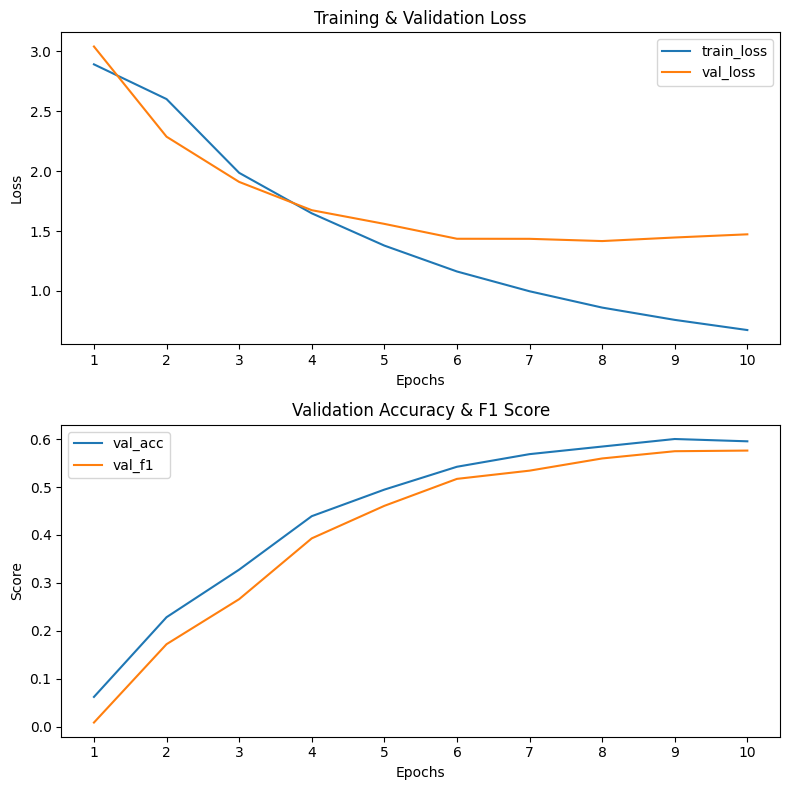

In [33]:
plot_history(gru_history)

### b) BiGru

In [34]:
# Bi-GRU 모델 학습
bigru_model = BiGRUModel(vocab_size=8000, embedding_dim=64).to(device)
bigru_history = train_test(bigru_model, 'BiGRU', epochs = 10, hidden_size=64, num_layers=2, lr=0.001, wd=1e-5, dropout=0.5)

학습 시작
Epoch [1/10], Train Loss: 2.2993
Val Loss: 1.7783, Acc: 0.3921, F1: 0.3504
 Best model saved! Val Acc: 0.3921
Epoch [2/10], Train Loss: 1.5262
Val Loss: 1.3664, Acc: 0.5458, F1: 0.5208
 Best model saved! Val Acc: 0.5458
Epoch [3/10], Train Loss: 1.1511
Val Loss: 1.2401, Acc: 0.6060, F1: 0.5803
 Best model saved! Val Acc: 0.6060
Epoch [4/10], Train Loss: 0.9578
Val Loss: 1.2081, Acc: 0.6280, F1: 0.6109
 Best model saved! Val Acc: 0.6280
Epoch [5/10], Train Loss: 0.8302
Val Loss: 1.1903, Acc: 0.6510, F1: 0.6274
 Best model saved! Val Acc: 0.6510
Epoch [6/10], Train Loss: 0.7105
Val Loss: 1.2492, Acc: 0.6360, F1: 0.6260
Epoch [7/10], Train Loss: 0.6507
Val Loss: 1.2783, Acc: 0.6547, F1: 0.6348
 Best model saved! Val Acc: 0.6547
Epoch [8/10], Train Loss: 0.5392
Val Loss: 1.3123, Acc: 0.6490, F1: 0.6305
Epoch [9/10], Train Loss: 0.5015
Val Loss: 1.3788, Acc: 0.6461, F1: 0.6323
Epoch [10/10], Train Loss: 0.4220
Val Loss: 1.4209, Acc: 0.6476, F1: 0.6341

 [BiGRU Model] 총 학습 시간: 66.38초 (

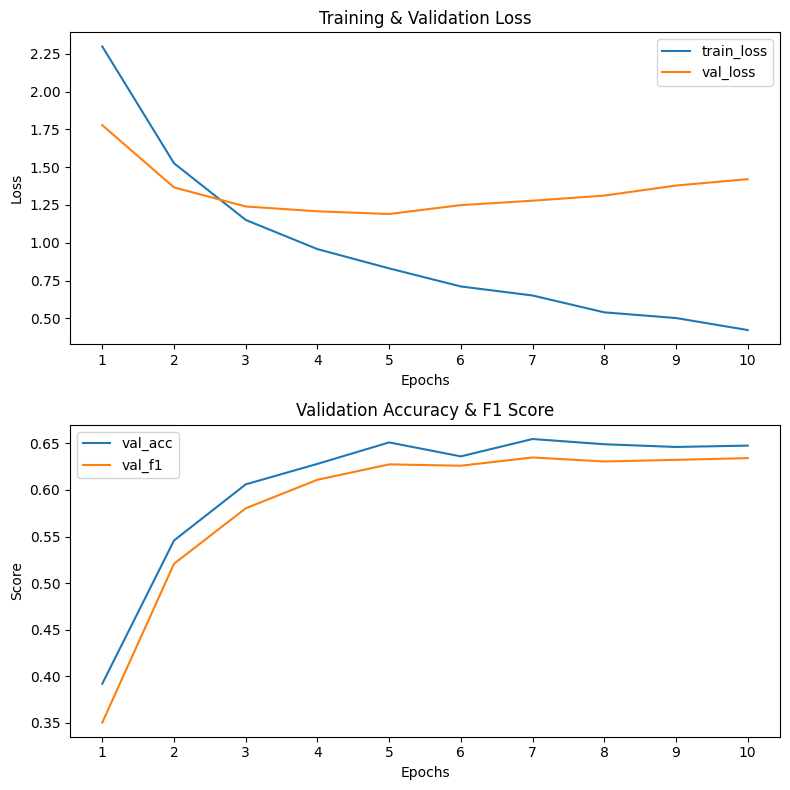

In [35]:
plot_history(bigru_history)

### c) Bi-Gru + Attention

In [36]:
# Bi-GRU + Attention 모델 학습
bigru_attn_model = BiGRUAttentionModel(vocab_size=8000, embedding_dim=64).to(device)
bigru_attn_history = train_test(bigru_attn_model, 'BiGRU+Attention', epochs = 10, hidden_size=64, num_layers=2, lr=0.001, wd=1e-5, dropout=0.5)

학습 시작
Epoch [1/10], Train Loss: 2.0814
Val Loss: 1.5115, Acc: 0.4958, F1: 0.4557
 Best model saved! Val Acc: 0.4958
Epoch [2/10], Train Loss: 1.2636
Val Loss: 1.2337, Acc: 0.6125, F1: 0.5846
 Best model saved! Val Acc: 0.6125
Epoch [3/10], Train Loss: 0.9909
Val Loss: 1.2222, Acc: 0.6295, F1: 0.6036
 Best model saved! Val Acc: 0.6295
Epoch [4/10], Train Loss: 0.8015
Val Loss: 1.1623, Acc: 0.6676, F1: 0.6417
 Best model saved! Val Acc: 0.6676
Epoch [5/10], Train Loss: 0.6607
Val Loss: 1.1898, Acc: 0.6629, F1: 0.6471
Epoch [6/10], Train Loss: 0.5390
Val Loss: 1.2801, Acc: 0.6519, F1: 0.6385
Epoch [7/10], Train Loss: 0.4419
Val Loss: 1.3954, Acc: 0.6547, F1: 0.6345
Epoch [8/10], Train Loss: 0.3708
Val Loss: 1.4677, Acc: 0.6643, F1: 0.6512
Epoch [9/10], Train Loss: 0.3066
Val Loss: 1.5606, Acc: 0.6575, F1: 0.6444
Epoch [10/10], Train Loss: 0.2612
Val Loss: 1.7030, Acc: 0.6485, F1: 0.6313

 [BiGRU+Attention Model] 총 학습 시간: 77.84초 (1.30분)


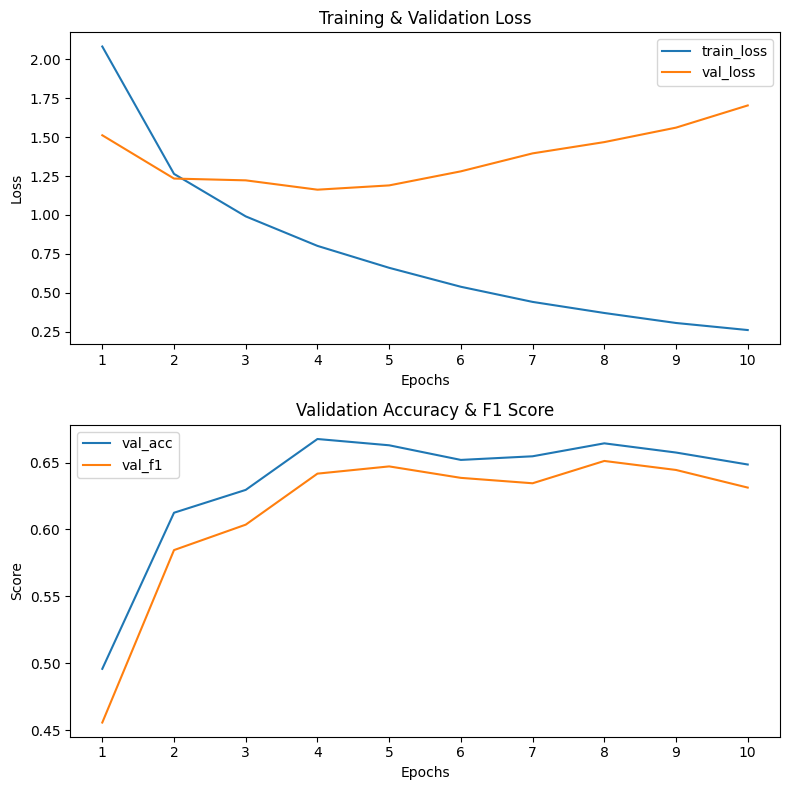

In [37]:
plot_history(bigru_attn_history)

## 4-3. 모델 비교

In [38]:
histories = {
    'GRU': gru_history,
    'BiGRU': bigru_history,
    'BiGRU+Attention': bigru_attn_history
}

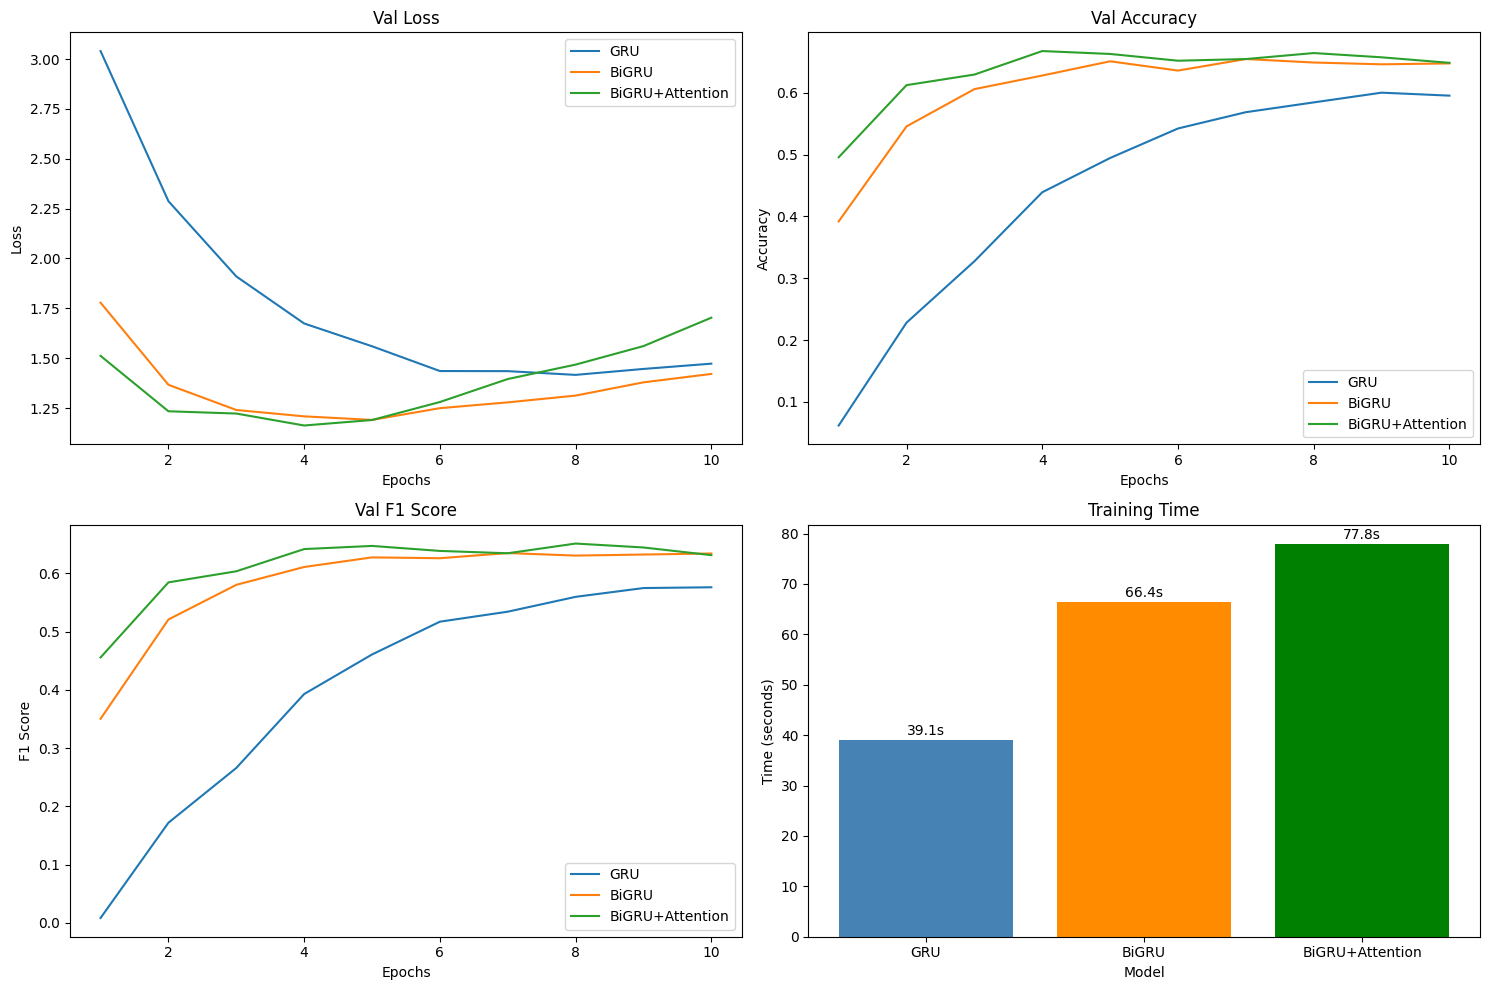

In [39]:
epochs_range = range(1, len(list(histories.values())[0]['val_loss']) + 1)

plt.figure(figsize=(15, 10))

# Val Loss 비교
ax1 = plt.subplot(2, 2, 1)
for model_name, history in histories.items():
    ax1.plot(epochs_range, history['val_loss'], label=model_name)
ax1.set_title('Val Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

# Val Accuracy 비교
ax2 = plt.subplot(2, 2, 2)
for model_name, history in histories.items():
    ax2.plot(epochs_range, history['val_acc'], label=model_name)
ax2.set_title('Val Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()

# Val F1 비교
ax3 = plt.subplot(2, 2, 3)
for model_name, history in histories.items():
    ax3.plot(epochs_range, history['val_f1'], label=model_name)
ax3.set_title('Val F1 Score')
ax3.set_xlabel('Epochs')
ax3.set_ylabel('F1 Score')
ax3.legend()

# 학습 시간 비교 (막대그래프)
ax4 = plt.subplot(2, 2, 4)
model_names = list(histories.keys())
times = [history['time'] for history in histories.values()]
ax4.bar(model_names, times, color=['steelblue', 'darkorange', 'green'])
ax4.set_title('Training Time')
ax4.set_xlabel('Model')
ax4.set_ylabel('Time (seconds)')
for i, t in enumerate(times):
    ax4.text(i, t + 1, f'{t:.1f}s', ha='center')

plt.tight_layout()
plt.show()

- GRU, Bi-GRU, BiGRU + Attention모델 모두 5에포크에서 과적합이 시작
- 정확도와 F1 Score 모두 전 구간에서 BIGRU + Attention 모델이 가장 높은 형태를 보임
- 학습 시간 자체는 BiGRU + Attention 모델이 가장 오래걸렸지만, 에포크 수가 많지 않기 때문에 감수할만한 시간이라고 생각해 튜닝할 모델로**BIGRU + Attention** 모델을 결정하게 되었다.

# 5\. 하이퍼파라미터튜닝

## 5-1. optuna활용

위에서 선언했던 train_test함수를 재활용하여 optuna를 수행했다.

In [41]:
def objective(trial):
    hidden_size = trial.suggest_categorical('hidden_size', [32, 64, 128])
    num_layers  = trial.suggest_int('num_layers', 1, 3)
    lr          = trial.suggest_float('lr', 1e-4, 1e-3, log=True)
    wd          = trial.suggest_float('wd', 1e-6, 1e-4, log=True)
    dropout     = trial.suggest_float('dropout', 0.3, 0.5)

    model = BiGRUAttentionModel(vocab_size=8000, embedding_dim=64,
                                hidden_size=hidden_size, num_layers=num_layers,
                                dropout=dropout).to(device)

    history = train_test(model, 'BiGRU+Attention', epochs=10, hidden_size=hidden_size, num_layers=num_layers,
                         lr=lr, wd=wd, dropout=dropout)

    #최고 val_acc 반환
    return max(history['val_acc'])

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20, show_progress_bar=True)  # 진행상황 표시

# 최적 파라미터 출력
print(f"\nBest Val Acc: {study.best_value:.4f}")
print(f"Best Params: {study.best_params}")

[I 2026-05-15 00:57:55,086] A new study created in memory with name: no-name-e0eee511-2621-4208-b75e-6d04e67d082f


  0%|          | 0/20 [00:00<?, ?it/s]

학습 시작


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1334: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3849761009948744 and num_layers=1
  super().__init__("GRU", *args, **kwargs)


Epoch [1/10], Train Loss: 2.9939
Val Loss: 2.9847, Acc: 0.0826, F1: 0.0408
 Best model saved! Val Acc: 0.0826
Epoch [2/10], Train Loss: 2.9775
Val Loss: 2.9672, Acc: 0.1153, F1: 0.0660
 Best model saved! Val Acc: 0.1153
Epoch [3/10], Train Loss: 2.9512
Val Loss: 2.9249, Acc: 0.1487, F1: 0.0820
 Best model saved! Val Acc: 0.1487
Epoch [4/10], Train Loss: 2.8176
Val Loss: 2.6483, Acc: 0.1596, F1: 0.0663
 Best model saved! Val Acc: 0.1596
Epoch [5/10], Train Loss: 2.5372
Val Loss: 2.4414, Acc: 0.2099, F1: 0.1016
 Best model saved! Val Acc: 0.2099
Epoch [6/10], Train Loss: 2.4074
Val Loss: 2.3421, Acc: 0.2244, F1: 0.1211
 Best model saved! Val Acc: 0.2244
Epoch [7/10], Train Loss: 2.3110
Val Loss: 2.2658, Acc: 0.2406, F1: 0.1427
 Best model saved! Val Acc: 0.2406
Epoch [8/10], Train Loss: 2.2197
Val Loss: 2.1869, Acc: 0.2590, F1: 0.1690
 Best model saved! Val Acc: 0.2590
Epoch [9/10], Train Loss: 2.1362
Val Loss: 2.1147, Acc: 0.2871, F1: 0.1987
 Best model saved! Val Acc: 0.2871
Epoch [10/

...

Epoch [1/10], Train Loss: 2.2833
Val Loss: 1.6292, Acc: 0.5023, F1: 0.4638
 Best model saved! Val Acc: 0.5023
Epoch [2/10], Train Loss: 1.2826
Val Loss: 1.2342, Acc: 0.6346, F1: 0.6113
 Best model saved! Val Acc: 0.6346
Epoch [3/10], Train Loss: 1.0113
Val Loss: 1.1634, Acc: 0.6608, F1: 0.6375
 Best model saved! Val Acc: 0.6608
Epoch [4/10], Train Loss: 0.8526
Val Loss: 1.1662, Acc: 0.6650, F1: 0.6450
 Best model saved! Val Acc: 0.6650
Epoch [5/10], Train Loss: 0.7271
Val Loss: 1.1742, Acc: 0.6749, F1: 0.6564
 Best model saved! Val Acc: 0.6749
Epoch [6/10], Train Loss: 0.6214
Val Loss: 1.2494, Acc: 0.6676, F1: 0.6499
Epoch [7/10], Train Loss: 0.5293
Val Loss: 1.3075, Acc: 0.6703, F1: 0.6493
Epoch [8/10], Train Loss: 0.4519
Val Loss: 1.3870, Acc: 0.6636, F1: 0.6468
Epoch [9/10], Train Loss: 0.3893
Val Loss: 1.4414, Acc: 0.6700, F1: 0.6549
Epoch [10/10], Train Loss: 0.3249
Val Loss: 1.5320, Acc: 0.6623, F1: 0.6442

 [BiGRU+Attention Model] 총 학습 시간: 41.62초 (0.69분)
[I 2026-05-15 01:15:40,7

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1334: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.34492178318054684 and num_layers=1
  super().__init__("GRU", *args, **kwargs)


Epoch [1/10], Train Loss: 2.2432
Val Loss: 1.5546, Acc: 0.5260, F1: 0.4926
 Best model saved! Val Acc: 0.5260
Epoch [2/10], Train Loss: 1.2502
Val Loss: 1.2502, Acc: 0.6133, F1: 0.5889
 Best model saved! Val Acc: 0.6133
Epoch [3/10], Train Loss: 0.9803
Val Loss: 1.1587, Acc: 0.6643, F1: 0.6426
 Best model saved! Val Acc: 0.6643
Epoch [4/10], Train Loss: 0.8280
Val Loss: 1.1500, Acc: 0.6702, F1: 0.6486
 Best model saved! Val Acc: 0.6702
Epoch [5/10], Train Loss: 0.7030
Val Loss: 1.1904, Acc: 0.6650, F1: 0.6481
Epoch [6/10], Train Loss: 0.6005
Val Loss: 1.2637, Acc: 0.6638, F1: 0.6475
Epoch [7/10], Train Loss: 0.5154
Val Loss: 1.3207, Acc: 0.6622, F1: 0.6443
Epoch [8/10], Train Loss: 0.4300
Val Loss: 1.4207, Acc: 0.6557, F1: 0.6348
Epoch [9/10], Train Loss: 0.3682
Val Loss: 1.4959, Acc: 0.6577, F1: 0.6422
Epoch [10/10], Train Loss: 0.3158
Val Loss: 1.5975, Acc: 0.6519, F1: 0.6374

 [BiGRU+Attention Model] 총 학습 시간: 40.80초 (0.68분)
[I 2026-05-15 01:16:21,586] Trial 18 finished with value: 0

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1334: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3653911359879318 and num_layers=1
  super().__init__("GRU", *args, **kwargs)


Epoch [1/10], Train Loss: 2.3075
Val Loss: 1.6727, Acc: 0.4382, F1: 0.3898
 Best model saved! Val Acc: 0.4382
Epoch [2/10], Train Loss: 1.3524
Val Loss: 1.2988, Acc: 0.5993, F1: 0.5633
 Best model saved! Val Acc: 0.5993
Epoch [3/10], Train Loss: 1.0501
Val Loss: 1.1906, Acc: 0.6494, F1: 0.6247
 Best model saved! Val Acc: 0.6494
Epoch [4/10], Train Loss: 0.8929
Val Loss: 1.1667, Acc: 0.6577, F1: 0.6343
 Best model saved! Val Acc: 0.6577
Epoch [5/10], Train Loss: 0.7782
Val Loss: 1.1725, Acc: 0.6680, F1: 0.6480
 Best model saved! Val Acc: 0.6680
Epoch [6/10], Train Loss: 0.6761
Val Loss: 1.2098, Acc: 0.6622, F1: 0.6381
Epoch [7/10], Train Loss: 0.5872
Val Loss: 1.2877, Acc: 0.6624, F1: 0.6456
Epoch [8/10], Train Loss: 0.5144
Val Loss: 1.3810, Acc: 0.6538, F1: 0.6377
Epoch [9/10], Train Loss: 0.4568
Val Loss: 1.4250, Acc: 0.6602, F1: 0.6448
Epoch [10/10], Train Loss: 0.3857
Val Loss: 1.4973, Acc: 0.6602, F1: 0.6435

 [BiGRU+Attention Model] 총 학습 시간: 40.90초 (0.68분)
[I 2026-05-15 01:17:02,5

In [42]:
#optuna에서 추출한 best parameter로 재학습
best_params = study.best_params

best_model = BiGRUAttentionModel(
    vocab_size=8000,
    embedding_dim=64,
    hidden_size=best_params['hidden_size'],
    num_layers=best_params['num_layers'],
    dropout=best_params['dropout']
).to(device)

best_history = train_test(
    best_model,
    'BiGRU+Attention_best',
    epochs=10,
    hidden_size=best_params['hidden_size'],
    num_layers=best_params['num_layers'],
    lr=best_params['lr'],
    wd=best_params['wd'],
    dropout=best_params['dropout']
)

학습 시작
Epoch [1/10], Train Loss: 2.2409
Val Loss: 1.5192, Acc: 0.5167, F1: 0.4646
 Best model saved! Val Acc: 0.5167
Epoch [2/10], Train Loss: 1.2425
Val Loss: 1.2380, Acc: 0.6291, F1: 0.6013
 Best model saved! Val Acc: 0.6291
Epoch [3/10], Train Loss: 0.9922
Val Loss: 1.1639, Acc: 0.6578, F1: 0.6359
 Best model saved! Val Acc: 0.6578
Epoch [4/10], Train Loss: 0.8444
Val Loss: 1.1409, Acc: 0.6665, F1: 0.6425
 Best model saved! Val Acc: 0.6665
Epoch [5/10], Train Loss: 0.7278
Val Loss: 1.1417, Acc: 0.6729, F1: 0.6484
 Best model saved! Val Acc: 0.6729
Epoch [6/10], Train Loss: 0.6278
Val Loss: 1.1712, Acc: 0.6758, F1: 0.6563
 Best model saved! Val Acc: 0.6758
Epoch [7/10], Train Loss: 0.5381
Val Loss: 1.2572, Acc: 0.6718, F1: 0.6506
Epoch [8/10], Train Loss: 0.4595
Val Loss: 1.3404, Acc: 0.6619, F1: 0.6474
Epoch [9/10], Train Loss: 0.3909
Val Loss: 1.3845, Acc: 0.6712, F1: 0.6575
Epoch [10/10], Train Loss: 0.3329
Val Loss: 1.4634, Acc: 0.6670, F1: 0.6506

 [BiGRU+Attention_best Model] 총 

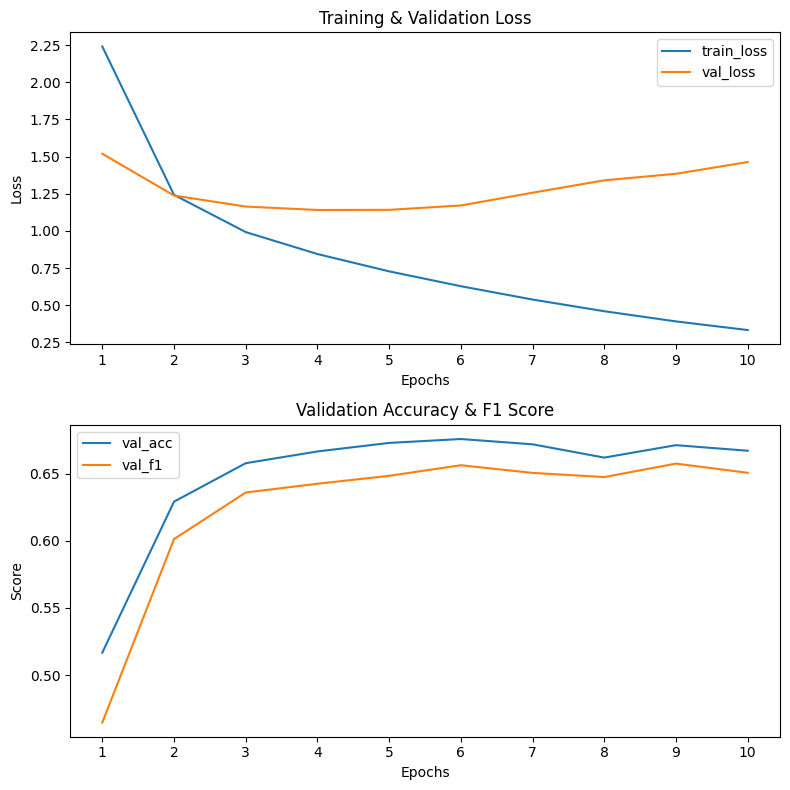

In [43]:
plot_history(best_history)

초반에 과적합이 일어나는것이 계속 관찰되어서, 하이퍼파라미터 튜닝 후 과적합을 완화시킬만한 튜닝들을 추가로 해보기로 결정했다.

## 5-2. +레이어 정규화 추가

best 모델로 선정되었던 BiGRU + Attention 모델과 하이퍼파라미터에, 모델에 레이어정규화를 추가하여 과적합이 완화되는지 실험해보았다.

In [44]:
#레이어 정규화 추가 모델 정의
class BiGRUAttention_LayerNormModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size=128, num_layers=2, num_classes=20, dropout=0.3):
        super(BiGRUAttention_LayerNormModel, self).__init__()

        # 임베딩 레이어 (Word2Vec 초기값 적용)
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.embedding.weight = nn.Parameter(embedding_matrix)

        # 양방향 GRU 레이어(num_layers가 1일때 dropout이 적용되지 않아 경고 발생하여 분기 추)
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # Layer Normalization 추가
        self.layer_norm = nn.LayerNorm(hidden_size * 2)

        # Attention 레이어
        self.attention = Attention(hidden_size)

        #Dropout 레이어
        self.dropout = nn.Dropout(dropout)

        # 분류 레이어
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        # 임베딩 레이어
        x = self.embedding(x)  # [batch_size, seq_len, embedding_dim]

        # 양방향 GRU 순전파
        out, _ = self.gru(x)  # out: [batch_size, seq_len, hidden_size * 2]

        # GRU 출력에 Layer Norm 적용
        out = self.layer_norm(out)

        # Attention 적용 (mean pooling 대신) + Dropout
        context = self.dropout(self.attention(out))  # [batch_size, hidden_size * 2]

        # 분류(최종 출력)
        out = self.fc(context)  # [batch_size, num_classes]

        return out

In [45]:
best_layernorm_model = BiGRUAttention_LayerNormModel(
    vocab_size=8000,
    embedding_dim=64,
    hidden_size=best_params['hidden_size'],
    num_layers=best_params['num_layers'],
    dropout=best_params['dropout']
).to(device)

best_layernorm_history = train_test(
    best_layernorm_model,
    'BiGRU+Attention_LayerNorm_best',
    epochs=10,
    hidden_size=best_params['hidden_size'],
    num_layers=best_params['num_layers'],
    lr=best_params['lr'],
    wd=best_params['wd'],
    dropout=best_params['dropout']
)

학습 시작
Epoch [1/10], Train Loss: 1.5973
Val Loss: 1.1919, Acc: 0.6486, F1: 0.6308
 Best model saved! Val Acc: 0.6486
Epoch [2/10], Train Loss: 1.0335
Val Loss: 1.0971, Acc: 0.6728, F1: 0.6537
 Best model saved! Val Acc: 0.6728
Epoch [3/10], Train Loss: 0.8787
Val Loss: 1.0973, Acc: 0.6747, F1: 0.6536
 Best model saved! Val Acc: 0.6747
Epoch [4/10], Train Loss: 0.7582
Val Loss: 1.1192, Acc: 0.6858, F1: 0.6692
 Best model saved! Val Acc: 0.6858
Epoch [5/10], Train Loss: 0.6462
Val Loss: 1.1899, Acc: 0.6789, F1: 0.6620
Epoch [6/10], Train Loss: 0.5411
Val Loss: 1.2416, Acc: 0.6733, F1: 0.6567
Epoch [7/10], Train Loss: 0.4593
Val Loss: 1.3438, Acc: 0.6759, F1: 0.6640
Epoch [8/10], Train Loss: 0.3773
Val Loss: 1.4674, Acc: 0.6693, F1: 0.6595
Epoch [9/10], Train Loss: 0.3141
Val Loss: 1.5968, Acc: 0.6649, F1: 0.6514
Epoch [10/10], Train Loss: 0.2577
Val Loss: 1.6816, Acc: 0.6677, F1: 0.6605

 [BiGRU+Attention_LayerNorm_best Model] 총 학습 시간: 42.58초 (0.71분)


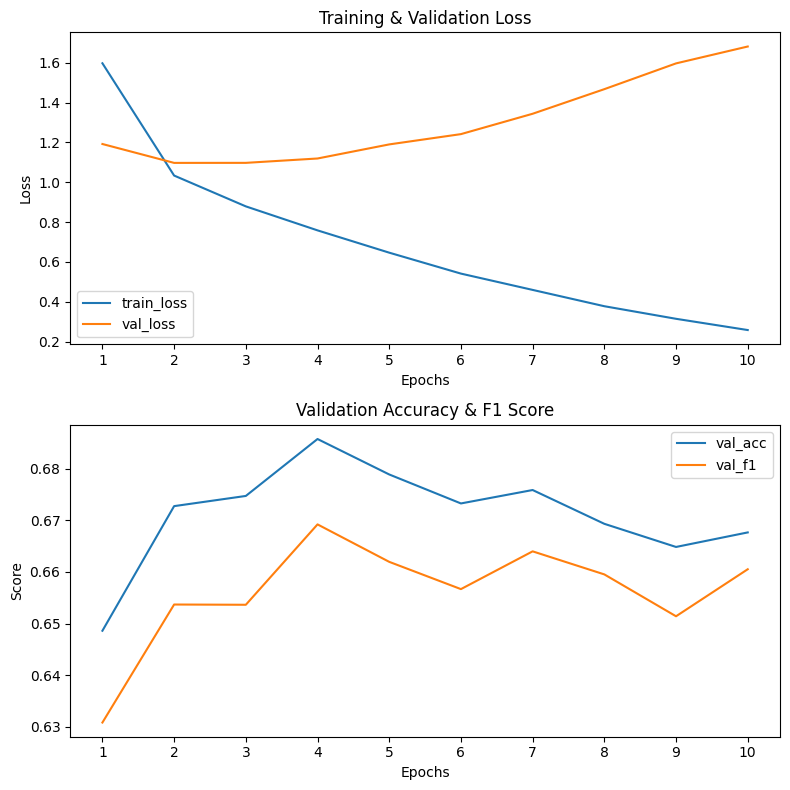

In [46]:
plot_history(best_layernorm_history)

LayerNorm을 추가했더니 오히려 성능지표가 떨어졌고, 과적합이 더 일찍 나타나는 모양새를 보여 굳이 추가할 필요 없다고 판단했다.

## 5-3. TF-IDF 기반 불용어 처리 추가

너무 자주 등장하는 토큰은 모든 클래스에서 공통적으로 나타나, 분류에 도움이 안되는 노이즈가 될 수 있기 때문에 상위 n개 토큰들을 불용어 처리하여 데이터셋을 재구성해, 성능지표를 보기로 했다.

In [49]:
# 전체 토큰 빈도 계산
all_tokens = [token for tokens in df['tokens'] for token in tokens]
token_counts = Counter(all_tokens)

print(f"전체 고유 토큰 수: {len(token_counts)}")
print(f"전체 토큰 등장 횟수: {len(all_tokens)}")
print(f"\n상위 20개 고빈도 토큰:")
for token, count in token_counts.most_common(20):
    print(f"{token}: {count}")

전체 고유 토큰 수: 7995
전체 토큰 등장 횟수: 4420479

상위 20개 고빈도 토큰:
.: 188106
▁the: 174081
s: 106971
▁to: 87740
▁a: 77771
▁of: 76660
▁and: 69370
x: 68143
a: 63322
▁in: 54284
▁i: 50431
▁is: 49374
▁that: 45827
▁it: 34152
▁for: 32988
▁you: 28883
▁.: 26832
ing: 26108
d: 24408
?: 24374


?, .은 문장부호이기 때문에, 그리고 s, x, a, ing등은 서브워드 조각이기 떄문에 냅두고, _로시작하는 고빈도 단어만 불용어 처리를 하기로 결정했다.

In [53]:
# ▁로 시작하는 고빈도 토큰만 불용어로 처리
high_freq_stopwords = set([
    token for token, count in token_counts.most_common(100)
    if token.startswith('▁')
])

print(f"제거할 토큰 수: {len(high_freq_stopwords)}")
print(high_freq_stopwords)

제거할 토큰 수: 70
{'▁them', '▁m', '▁but', '▁i', '▁out', '▁no', '▁you', '▁have', '▁an', '▁all', '▁my', '▁me', '▁some', '▁other', '▁just', '▁had', '▁on', '▁he', '▁x', '▁not', '▁for', '▁which', '▁can', '▁at', '▁a', '▁one', '▁like', '▁any', '▁were', '▁people', '▁know', '▁by', '▁who', '▁only', '▁do', '▁so', '▁your', '▁their', '▁is', '▁are', '▁they', '▁when', '▁more', '▁up', '▁of', '▁and', '▁as', '▁the', '▁will', '▁its', '▁dont', '▁with', '▁there', '▁what', '▁get', '▁.', '▁if', '▁we', '▁about', '▁to', '▁that', '▁was', '▁or', '▁would', '▁from', '▁in', '▁it', '▁be', '▁this', '▁has'}


약 70개의 자주 등장하는 토큰을 불용어처리하여 진행했다.

In [54]:
#불용어 처리 추가 encode로직
def encode_filtered(text):
    result = []
    for sent in sent_tokenize(text):
        sent = sent.strip()
        if sent:
            ids = [sp.bos_id()] + [
                id for id, token in zip(sp.encode(sent, out_type=int), sp.encode(sent, out_type=str))
                if token not in high_freq_stopwords
            ] + [sp.eos_id()]
            result.extend(ids)
    return result

df['input_ids'] = df['text_clean'].apply(encode_filtered)

In [55]:
#새로운 input_id(불용어 포함)이용 데이터셋 생성

# train/val/test split
train_df, val_test_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(val_test_df, test_size=0.5, random_state=42)

#split하면 원본 df의 인덱스가 유지되므로 reset_index
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# Dataset 생성
train_dataset = NewsDataset(train_df, sp)
val_dataset = NewsDataset(val_df, sp)
test_dataset = NewsDataset(test_df, sp)

# DataLoader 생성
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, pin_memory=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, pin_memory=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, pin_memory=True, num_workers=2)

print(f"train: {len(train_dataset)}, val: {len(val_dataset)}, test: {len(test_dataset)}")

train: 15076, val: 1885, test: 1885


In [56]:
#optuna에서 추출한 best parameter + 불용어 처리 데이터셋으로 재학습
best_model_stopwords = BiGRUAttentionModel(
    vocab_size=8000,
    embedding_dim=64,
    hidden_size=best_params['hidden_size'],
    num_layers=best_params['num_layers'],
    dropout=best_params['dropout']
).to(device)

best_stopwords_history = train_test(
    best_model_stopwords,
    'BiGRU+Attention_stopwords_best',
    epochs=10,
    hidden_size=best_params['hidden_size'],
    num_layers=best_params['num_layers'],
    lr=best_params['lr'],
    wd=best_params['wd'],
    dropout=best_params['dropout']
)

학습 시작


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1334: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.4015132083103173 and num_layers=1
  super().__init__("GRU", *args, **kwargs)


Epoch [1/10], Train Loss: 2.1872
Val Loss: 1.5512, Acc: 0.5076, F1: 0.4645
 Best model saved! Val Acc: 0.5076
Epoch [2/10], Train Loss: 1.2828
Val Loss: 1.2570, Acc: 0.6206, F1: 0.5954
 Best model saved! Val Acc: 0.6206
Epoch [3/10], Train Loss: 1.0152
Val Loss: 1.1751, Acc: 0.6503, F1: 0.6272
 Best model saved! Val Acc: 0.6503
Epoch [4/10], Train Loss: 0.8513
Val Loss: 1.1492, Acc: 0.6564, F1: 0.6373
 Best model saved! Val Acc: 0.6564
Epoch [5/10], Train Loss: 0.7267
Val Loss: 1.1635, Acc: 0.6723, F1: 0.6566
 Best model saved! Val Acc: 0.6723
Epoch [6/10], Train Loss: 0.6303
Val Loss: 1.1920, Acc: 0.6690, F1: 0.6545
Epoch [7/10], Train Loss: 0.5301
Val Loss: 1.2991, Acc: 0.6657, F1: 0.6511
Epoch [8/10], Train Loss: 0.4564
Val Loss: 1.3267, Acc: 0.6654, F1: 0.6532
Epoch [9/10], Train Loss: 0.3945
Val Loss: 1.4526, Acc: 0.6632, F1: 0.6468
Epoch [10/10], Train Loss: 0.3359
Val Loss: 1.5103, Acc: 0.6692, F1: 0.6578

 [BiGRU+Attention_stopwords_best Model] 총 학습 시간: 44.19초 (0.74분)


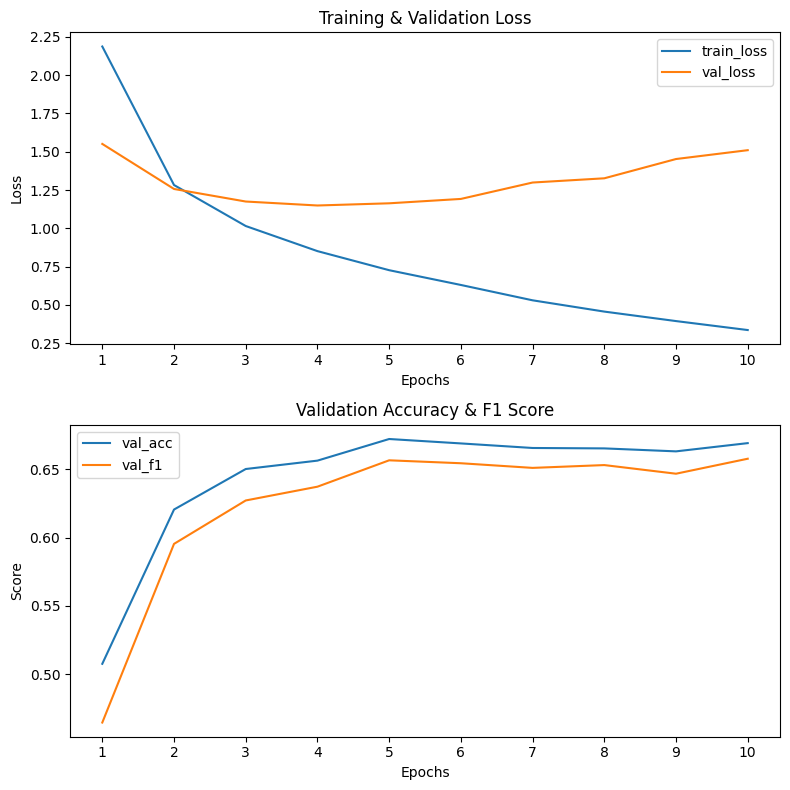

In [57]:
plot_history(best_stopwords_history)

## 5-4. 비교분석

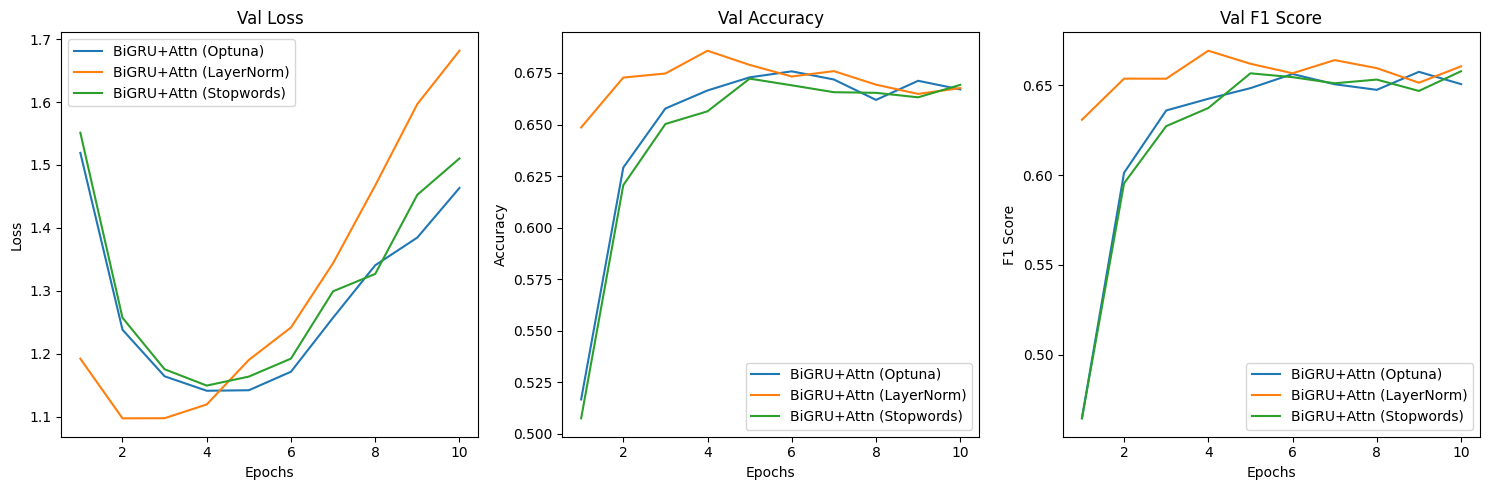

In [58]:
compare_histories = {
    'BiGRU+Attn (Optuna)': best_history,
    'BiGRU+Attn (LayerNorm)': best_layernorm_history,
    'BiGRU+Attn (Stopwords)': best_stopwords_history
}

epochs_range = range(1, len(list(compare_histories.values())[0]['val_loss']) + 1)

plt.figure(figsize=(15, 5))

# Val Loss 비교
ax1 = plt.subplot(1, 3, 1)
for model_name, history in compare_histories.items():
    ax1.plot(epochs_range, history['val_loss'], label=model_name)
ax1.set_title('Val Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

# Val Accuracy 비교
ax2 = plt.subplot(1, 3, 2)
for model_name, history in compare_histories.items():
    ax2.plot(epochs_range, history['val_acc'], label=model_name)
ax2.set_title('Val Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()

# Val F1 비교
ax3 = plt.subplot(1, 3, 3)
for model_name, history in compare_histories.items():
    ax3.plot(epochs_range, history['val_f1'], label=model_name)
ax3.set_title('Val F1 Score')
ax3.set_xlabel('Epochs')
ax3.set_ylabel('F1 Score')
ax3.legend()

plt.tight_layout()
plt.show()

Val Loss

- LayerNorm이 가장 빨리 과적합 시작
- Optuna랑 Stopwords는 비슷한 패턴

Val Accuracy

- LayerNorm이 초반에 가장 높지만 후반에 수렴
- Optuna랑 Stopwords는 거의 동일

Val F1

- 세 모델 모두 후반에 수렴 (~0.65)
- LayerNorm이 초반에 살짝 앞서지만 결국 비슷




결론 : 세 모델이 결국 비슷한 성능으로 수렴하여, 큰 차이가 없다고 판단했다. 따라서 **가장 단순하게 optuna 베스트 파라미터 모델로 test데이터 최종 평가**를 하는게 나을 것 같다고 판단했다.**과적합이 이르게 시작하는 것은, RNN모델의 한계라고 파악했다**.

# 6\. 최종 평가

In [61]:
# 저장된 best 모델 가중치 불러오기
best_model.load_state_dict(torch.load('./checkpoints/BiGRU+Attention_best_best.pt'))
best_model.eval()

f1_metric = F1Score(task='multiclass', num_classes=20, average='macro').to(device)
cm_metric = ConfusionMatrix(task='multiclass', num_classes=20).to(device)
total_acc = 0.0
all_preds = []   # 실제 예측 샘플 출력용
all_labels = []  # 실제 예측 샘플 출력용

with torch.no_grad():
    for input, labels in test_loader:
        input_ids = input.long().to(device)
        labels = labels.to(device)

        # 순전파
        outputs = best_model(input_ids)
        # 가장 높은 확률의 클래스를 예측값으로 선택
        preds = outputs.argmax(dim=1)

        acc = (preds == labels).sum() / len(labels)
        total_acc += acc

        # 배치별 누적
        f1_metric.update(preds, labels)
        cm_metric.update(preds, labels)

        # 실제 예측 샘플 출력용
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

avg_acc = total_acc / len(test_loader)
avg_f1 = f1_metric.compute()

print(f"Test Accuracy: {avg_acc:.4f}")
print(f"Test F1 Score: {avg_f1:.4f}")


Test Accuracy: 0.6635
Test F1 Score: 0.6528


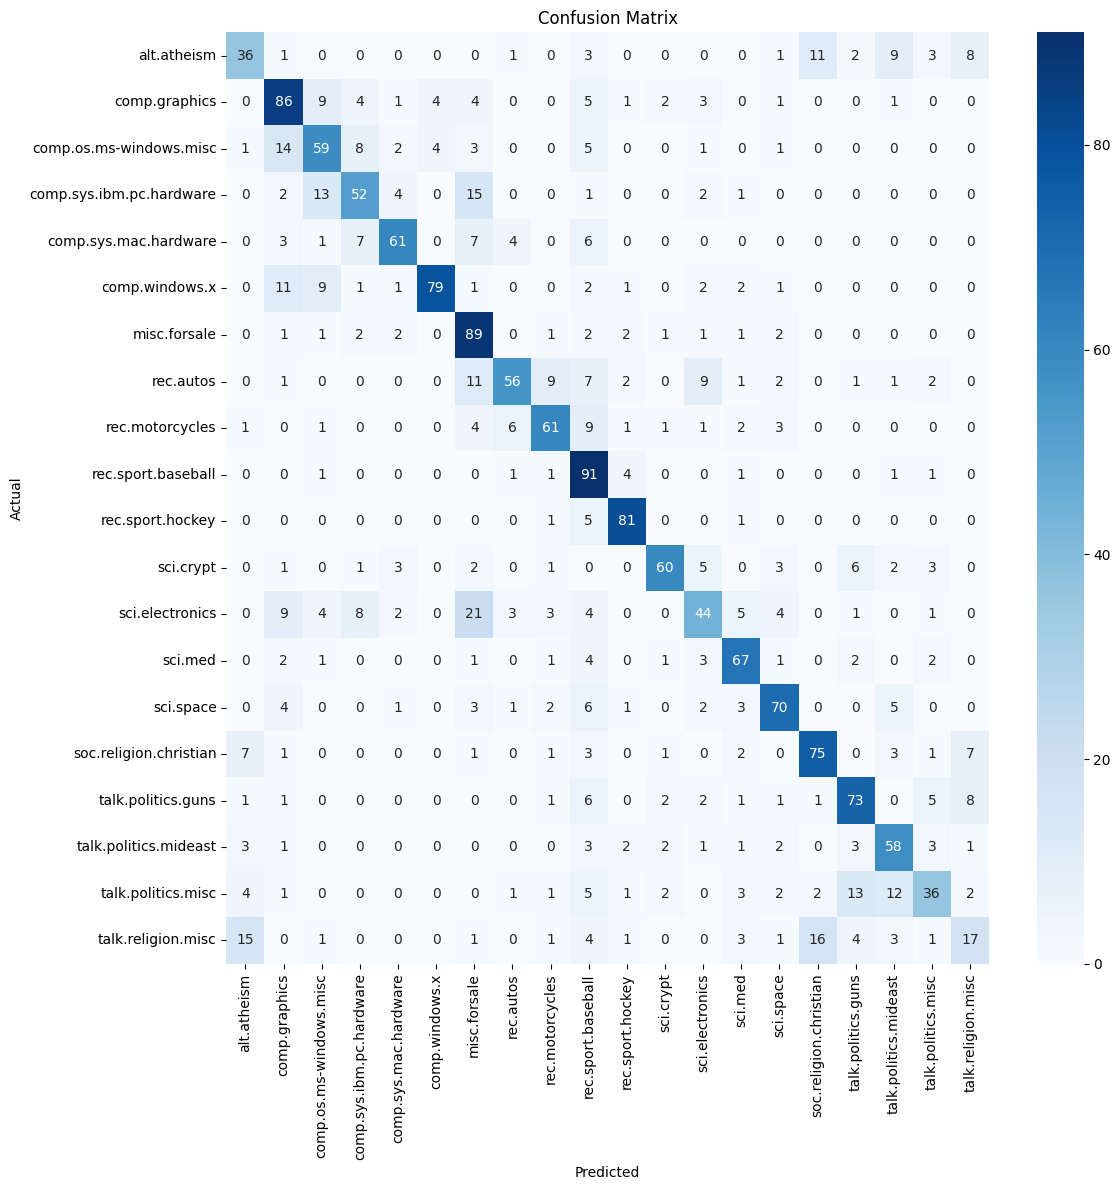

In [64]:
# 혼동행렬 시각화 (행: 실제 클래스, 열: 예측 클래스)
cm = cm_metric.compute().cpu().numpy()
plt.figure(figsize=(12, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=news_data.target_names,
            yticklabels=news_data.target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

분석
- talk.politics.misc를 talk.politics.guns, talk.politics.mideast으로 혼동

->정치 카테고리 끼리 혼동
- alt.atheism카테고리를 talk.religion.misc, soc.religion.christian 으로 혼동,
talk.religion.misc을 alt.atheism 으로 혼동

-> 종교 카테고리끼리 혼동이 있었다.

- 반면 스포츠 카테고리에서는 잘 분류가 되었다.

# 결론

약 66%의 정확도를 보였고, 정치/종교 카테고리처럼 주제가 겹치는 클래스는 사람도 충분히 헷갈릴 수 있기에, RNN모델을 사용했다고 감안했을 때 괜찮은 정확도를 보였다고 생각했다.

추후에 더 고도화된 모델을 실습하게 된다면, 추가적인 성능향상을 기대해볼 수 있을 것이라고 생각이 든다.